# Thư viện OpenCV

In [2]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

In [3]:
ROOT = "../../data/deskew_autocrop_normalize"

img_deskew = 'deskew.png'
img_autocrop = 'auto-crop.png'
img_normalize = 'normalize.jpg'

path_deskew = os.path.join(ROOT, img_deskew)
path_crop = os.path.join(ROOT, img_autocrop)
path_normalize = os.path.join(ROOT, img_normalize)


image = cv2.imread(path_deskew)
image_crop = cv2.imread(path_crop)
image_normalize = cv2.imread(path_normalize)

# Deskew_Image

In [4]:
def deskew(image_path):
    # Đọc ảnh và chuyển sang ảnh xám
    img = cv2.imread(path_deskew)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Đảo ngược màu (văn bản trắng trên nền đen) để tính toán dễ hơn
    # Dùng Threshold hoặc Canny để lấy các vùng chứa chữ
    gray = cv2.bitwise_not(gray)
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)[1]

    # Tìm tất cả các tọa độ pixel có giá trị > 0 
    coords = np.column_stack(np.where(thresh > 0))

    # Tìm hình chữ nhật có diện tích nhỏ nhất bao quanh tất cả các điểm đó
    # Hàm này trả về ((x,y), (w,h), angle)
    angle = cv2.minAreaRect(coords)[-1]

    # Điều chỉnh góc xoay
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    # Xoay ảnh
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

    return img, rotated, angle

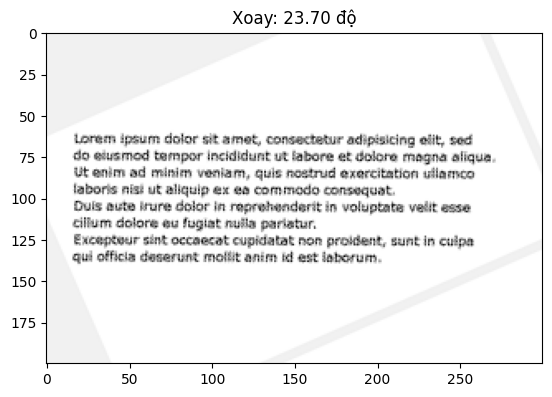

In [5]:
# Hiển thị kết quả
original_img, processed_img, angle = deskew(image)

plt.imshow(cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB))
plt.title(f"Xoay: {angle:.2f} độ")
plt.show()

# Auto-crop

In [ ]:
# Sắp xếp lại 4 điểm 
def order_points(pts):
    pts = pts.reshape(4, 2)
    rect = np.zeros((4, 2), dtype="float32")

    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]  # top-left
    rect[2] = pts[np.argmax(s)]  # bottom-right

    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]  # top-right
    rect[3] = pts[np.argmax(diff)]  # bottom-left

    return rect

# Transform phối cảnh
def four_point_transform(image, pts):
    rect = order_points(pts)
    (tl, tr, br, bl) = rect

    # Tính width và height mới
    widthA = np.linalg.norm(br - bl)
    widthB = np.linalg.norm(tr - tl)
    maxWidth = int(max(widthA, widthB))

    heightA = np.linalg.norm(tr - br)
    heightB = np.linalg.norm(tl - bl)
    maxHeight = int(max(heightA, heightB))

    # Destination points
    dst = np.array([
        [0, 0],
        [maxWidth - 1, 0],
        [maxWidth - 1, maxHeight - 1],
        [0, maxHeight - 1]
    ], dtype="float32")

    # Transform
    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (maxWidth, maxHeight))

    return warped

# Detect document (robust)
def detect_document(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Blur để giảm noise
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)

    # Edge detection
    edged = cv2.Canny(blurred, 30, 100)

    # Morphology để nối cạnh
    kernel = np.ones((5, 5), np.uint8)
    edged = cv2.dilate(edged, kernel, iterations=1)
    edged = cv2.erode(edged, kernel, iterations=1)

    # Find contours
    contours, _ = cv2.findContours(edged, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)

    # Tìm polygon 4 cạnh
    for c in contours[:10]:  # chỉ xét top lớn nhất
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.02 * peri, True)

        if len(approx) == 4:
            return approx

    return None

# Enhance ảnh (scan effect)
def enhance_scan(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Adaptive threshold
    th = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11, 2
    )

    return th

# Pipeline chính
def scan_document(image_path):
    image = cv2.imread(path_crop)
    if image is None:
        raise ValueError("Không đọc được ảnh")
    orig = image.copy()

    # Resize để tăng tốc + ổn định
    ratio = image.shape[0] / 500.0
    image = cv2.resize(image, (int(image.shape[1] / ratio), 500))

    # Detect document
    doc_cnt = detect_document(image)

    if doc_cnt is None:
        print("Không detect được document → fallback crop")
        return orig

    # Scale lại contour về ảnh gốc
    doc_cnt = doc_cnt.reshape(4, 2) * ratio

    # Transform phối cảnh
    warped = four_point_transform(orig, doc_cnt)

    # Enhance
    scanned = enhance_scan(warped)

    return scanned

result = scan_document(image_crop)
cv2_imshow(result)

# Background color processing

In [ ]:
def process_document(image_path):
    img = cv2.imread(path_normalize)
    if img is None:
        print("Không tìm thấy file ảnh!")
        return

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Khử nhiễu
    denoised = cv2.fastNlMeansDenoising(gray, None, h=10, templateWindowSize=7, searchWindowSize=21)

    # Tẩy nền bằng Adaptive Thresholding
    result = cv2.adaptiveThreshold(
        denoised, 
        255, 
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
        cv2.THRESH_BINARY, 
        41, # Kích thước vùng tính toán 
        15  # Hằng số C: Càng cao thì nền càng trắng sạch
    )

    return result

result = process_document(image_normalize)
cv2_imshow(result)
